Ocultando mensaje: 'The world has changed' (168 bits)


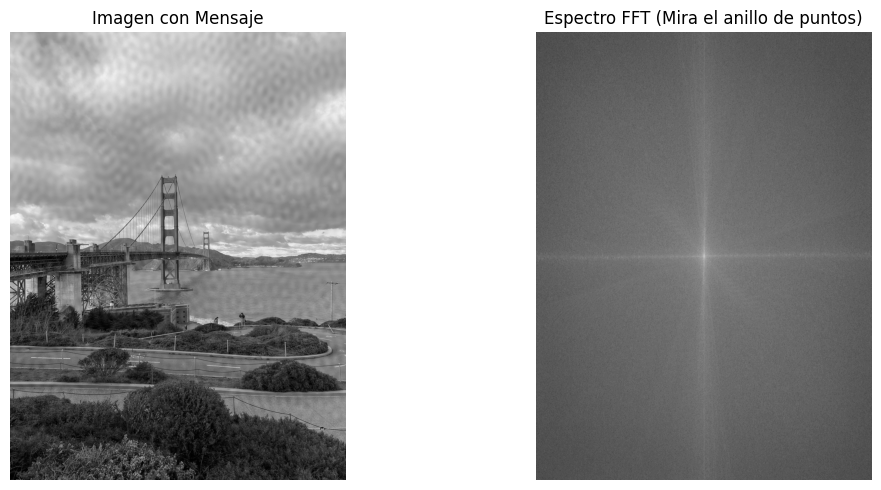

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- PASO PREVIO: Función para convertir texto a binario ---
def texto_a_binario(texto):
    return ''.join(format(ord(caracter), '08b') for caracter in texto)

# 1. Cargar la imagen y preparar el mensaje
imagen_original = np.array(Image.open('foto.jpg').convert('L'))
mensaje_secreto = "The world has changed" # <--- ¡AQUÍ ESTÁ TU MENSAJE!
bits_mensaje = texto_a_binario(mensaje_secreto)
num_bits = len(bits_mensaje)

print(f"Ocultando mensaje: '{mensaje_secreto}' ({num_bits} bits)")

# 2. Aplicar la Transformada Rápida de Fourier 2D
fft_2d = np.fft.fft2(imagen_original)
fft_shift = np.fft.fftshift(fft_2d)
magnitud = np.abs(fft_shift)
fase = np.angle(fft_shift)

# 3. ¡AQUÍ AGREGAMOS EL MENSAJE! (Distribución circular)
filas, columnas = imagen_original.shape
cy, cx = filas // 2, columnas // 2
radio = 40 # Radio del anillo de frecuencias medias
marca_intensidad = 1000000 # Energía que inyectaremos por cada bit '1'

# Recorremos cada bit del mensaje
for i, bit in enumerate(bits_mensaje):
    if bit == '1':
        # Calculamos el ángulo para distribuir los bits en un semicírculo
        # Usamos pi (180 grados) para la primera mitad, la simetría hará la otra mitad
        angulo = i * (np.pi / num_bits)

        # Convertimos coordenadas polares a cartesianas (y, x)
        dy = int(radio * np.sin(angulo))
        dx = int(radio * np.cos(angulo))

        # Inyectamos el bit 1 de forma SIMÉTRICA (Crucial en Fourier)
        magnitud[cy - dy, cx - dx] += marca_intensidad
        magnitud[cy + dy, cx + dx] += marca_intensidad

# 4. Reconstruir la imagen
fft_shift_modificada = magnitud * np.exp(1j * fase)
fft_inversa = np.fft.ifftshift(fft_shift_modificada)
imagen_esteganografica = np.abs(np.fft.ifft2(fft_inversa))

# Guardar la imagen
imagen_salida = Image.fromarray(np.clip(imagen_esteganografica, 0, 255).astype(np.uint8))
imagen_salida.save('imagen_secreta_hola.png')

# Visualización del Espectro Modificado (¡Aquí verás tu mensaje!)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen con Mensaje")
plt.imshow(imagen_esteganografica, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Espectro FFT (Mira el anillo de puntos)")
# Usamos logaritmo para que el espectro sea visible al ojo humano
plt.imshow(np.log(magnitud + 1), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from PIL import Image

# --- PASO PREVIO: Función para convertir binario a texto ---
def binario_a_texto(binario):
    caracteres = [chr(int(binario[i:i+8], 2)) for i in range(0, len(binario), 8)]
    return ''.join(caracteres)

# 1. Leer la imagen
imagen_recibida = np.array(Image.open('imagen_secreta_hola.png').convert('L'))

# 2. Aplicar FFT 2D
fft_recibida = np.fft.fft2(imagen_recibida)
fft_shift_recibida = np.fft.fftshift(fft_recibida)
magnitud_recibida = np.abs(fft_shift_recibida)

# 3. Parámetros acordados (La "Llave")
filas, columnas = imagen_recibida.shape
cy, cx = filas // 2, columnas // 2
radio = 40
num_bits = 32 # 4 letras * 8 bits
UMBRAL = 500000 # Límite para decidir si es 1 o 0

bits_recuperados = ""

# 4. Leer el anillo de frecuencias
for i in range(num_bits):
    angulo = i * (np.pi / num_bits)
    dy = int(radio * np.sin(angulo))
    dx = int(radio * np.cos(angulo))

    # Leemos la energía en esa coordenada
    energia = magnitud_recibida[cy - dy, cx - dx]

    # Decodificamos
    if energia > UMBRAL:
        bits_recuperados += "1"
    else:
        bits_recuperados += "0"

# 5. Traducir bits a texto
mensaje_final = binario_a_texto(bits_recuperados)
print(f"Bits extraídos: {bits_recuperados}")
print(f"¡MENSAJE OCULTO DESCIFRADO!: {mensaje_final}")

Bits extraídos: 01101101110101101101100100011100
¡MENSAJE OCULTO DESCIFRADO!: mÖÙ
